# Chain Diagnostics Notebook

This standalone notebook loads the saved Stage 4, Stage 5, and Stage 6 chain outputs from `crypto_stage1_processed/sgmcmc_results` and computes convergence diagnostics without rerunning the samplers.

## What this notebook covers

- Finds the latest saved run for each method.
- Loads per-chain posterior summary draws and runtime metadata.
- Computes `R-hat`, bulk `ESS`, tail `ESS`, and ESS-per-second.
- Shows quick posterior summaries and trace plots for a few monitored variables.
- Compares the smoothed high-volatility state probability across methods.

In [35]:
import json
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

## Paths and table I/O helpers

These helpers make the notebook work whether the saved tables are in parquet or pickle format.

In [38]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'crypto_stage1_processed'
RESULTS_DIR = DATA_DIR / 'sgmcmc_results'

METHOD_ROOTS = {
    'uniform': RESULTS_DIR / 'uniform',
    'young_static': RESULTS_DIR / 'young_static',
    'online_feature': RESULTS_DIR / 'online_feature',
}


def has_parquet_engine() -> bool:
    try:
        import pyarrow  # noqa: F401
        return True
    except Exception:
        try:
            import fastparquet  # noqa: F401
            return True
        except Exception:
            return False


TABULAR_EXT = '.parquet' if has_parquet_engine() else '.pkl'


def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = [base] if base.suffix in {'.parquet', '.pkl'} else [base.with_suffix('.parquet'), base.with_suffix('.pkl')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No saved table found for {base}')


def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    if path.suffix == '.pkl':
        return pd.read_pickle(path)
    raise ValueError(f'Unsupported table suffix: {path.suffix}')

## Locate the latest saved run for each method

If you want to inspect a different run, replace one of the entries in `METHOD_DIRS` after this cell runs.

In [41]:
def list_run_dirs(method_root: Path):
    if not method_root.exists():
        return []
    return sorted([p for p in method_root.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)


def latest_run_dir(method_root: Path):
    run_dirs = list_run_dirs(method_root)
    if not run_dirs:
        raise FileNotFoundError(f'No saved runs found in {method_root}')
    return run_dirs[-1]


def summary_base(run_dir: Path, stem: str) -> Path:
    summaries_dir = run_dir / 'summaries'
    return (summaries_dir / stem) if summaries_dir.exists() else (run_dir / stem)


def artifact_base(run_dir: Path, stem: str) -> Path:
    artifacts_dir = run_dir / 'artifacts'
    return (artifacts_dir / stem) if artifacts_dir.exists() else (run_dir / stem)


def chain_root(run_dir: Path) -> Path:
    candidate = run_dir / 'chains'
    return candidate if candidate.exists() else run_dir


METHOD_DIRS = {method: latest_run_dir(root) for method, root in METHOD_ROOTS.items()}

pd.DataFrame({
    'method': list(METHOD_DIRS.keys()),
    'run_dir': [str(path) for path in METHOD_DIRS.values()],
})

,method,run_dir
0,uniform,/Users/diego/Stat 221/crypto_stage1_processed/...
1,young_static,/Users/diego/Stat 221/crypto_stage1_processed/...
2,online_feature,/Users/diego/Stat 221/crypto_stage1_processed/...


## Load saved chain draws and trace tables

Each method stores one posterior-summary table per chain. Those are enough for convergence diagnostics.

In [44]:
def load_run_config(run_dir: Path):
    with open(run_dir / 'run_config.json', 'r') as f:
        return json.load(f)


def load_chain_samples(run_dir: Path):
    base = chain_root(run_dir)
    chain_dirs = sorted([p for p in base.glob('chain_*') if p.is_dir()], key=lambda p: int(p.name.split('_')[-1]))
    if not chain_dirs:
        chain_dirs = [run_dir]

    chain_dfs = []
    runtimes = []
    trace_dfs = []

    for chain_dir in chain_dirs:
        chain_dfs.append(read_table(chain_dir / 'posterior_summary_samples').copy())
        trace_dfs.append(read_table(chain_dir / 'trace_df').copy())

        run_cfg_path = chain_dir / 'run_config.json'
        if run_cfg_path.exists():
            with open(run_cfg_path, 'r') as f:
                cfg = json.load(f)
            runtimes.append(cfg.get('runtime_seconds', np.nan))
        else:
            runtimes.append(np.nan)

    return chain_dfs, trace_dfs, np.array(runtimes, dtype=float)


def load_smoothed_probs(run_dir: Path):
    return read_table(summary_base(run_dir, 'smoothed_state_probs')).copy()

## Diagnostics helpers

These functions convert the saved per-chain summaries into ArviZ objects and tidy diagnostic tables.

In [47]:
MONITORED_VARS = [
    'nu',
    'pi_0', 'pi_1', 'pi_2',
    'A_00', 'A_11', 'A_22',
    'trace_Sigma_0', 'trace_Sigma_1', 'trace_Sigma_2',
    'mu_0_0', 'mu_1_0', 'mu_2_0',
]

TRACE_VARS = [
    'nu',
    'A_00', 'A_11', 'A_22',
    'trace_Sigma_0', 'trace_Sigma_1', 'trace_Sigma_2',
]


def summary_dfs_to_inferencedata(chain_dfs, var_names=None):
    if var_names is None:
        var_names = [c for c in chain_dfs[0].columns if c != 'step']
    else:
        var_names = [v for v in var_names if v in chain_dfs[0].columns]

    n_draws = min(len(df) for df in chain_dfs)
    posterior = {}
    for v in var_names:
        posterior[v] = np.stack([df[v].to_numpy()[:n_draws] for df in chain_dfs], axis=0)
    return az.from_dict(posterior=posterior)


def dataset_to_tidy_metric(ds, value_name):
    arr = ds.to_array().rename(value_name)
    tidy = arr.to_dataframe().reset_index()
    if 'variable' not in tidy.columns:
        first_col = tidy.columns[0]
        tidy = tidy.rename(columns={first_col: 'variable'})
    return tidy


def compute_mcmc_diagnostics(chain_dfs, runtimes=None, monitored_vars=None):
    if len(chain_dfs) < 2:
        raise ValueError('Need at least two chains to compute R-hat and ESS diagnostics.')

    idata = summary_dfs_to_inferencedata(chain_dfs, var_names=monitored_vars)
    rhat = az.rhat(idata)
    ess_bulk = az.ess(idata, method='bulk')
    ess_tail = az.ess(idata, method='tail')

    rhat_df = dataset_to_tidy_metric(rhat, 'rhat')
    ess_bulk_df = dataset_to_tidy_metric(ess_bulk, 'ess_bulk')
    ess_tail_df = dataset_to_tidy_metric(ess_tail, 'ess_tail')

    join_cols = [c for c in rhat_df.columns if c != 'rhat']
    diag_df = rhat_df.merge(ess_bulk_df, on=join_cols, how='outer')
    join_cols = [c for c in diag_df.columns if c not in {'rhat', 'ess_bulk'}]
    diag_df = diag_df.merge(ess_tail_df, on=join_cols, how='outer')

    if runtimes is not None and np.isfinite(runtimes).all():
        runtime_mean = float(np.mean(runtimes))
        diag_df['runtime_sec_mean'] = runtime_mean
        diag_df['ess_bulk_per_sec'] = diag_df['ess_bulk'] / runtime_mean
        diag_df['ess_tail_per_sec'] = diag_df['ess_tail'] / runtime_mean

    return idata, diag_df


def posterior_summary_from_chain_dfs(chain_dfs, var_names):
    rows = []
    for var in var_names:
        arr = np.concatenate([df[var].to_numpy() for df in chain_dfs if var in df.columns])
        rows.append({
            'variable': var,
            'mean': float(np.mean(arr)),
            'sd': float(np.std(arr, ddof=1)),
            'q05': float(np.quantile(arr, 0.05)),
            'median': float(np.quantile(arr, 0.50)),
            'q95': float(np.quantile(arr, 0.95)),
        })
    return pd.DataFrame(rows)

## Compute R-hat and ESS for each method

This is the main chain-diagnostics table. Lower `R-hat` is better, while larger ESS is better.

In [50]:
method_diagnostics = {}

for method_name, method_dir in METHOD_DIRS.items():
    chain_dfs, trace_dfs, runtimes = load_chain_samples(method_dir)
    idata, diag_df = compute_mcmc_diagnostics(
        chain_dfs=chain_dfs,
        runtimes=runtimes,
        monitored_vars=MONITORED_VARS,
    )
    method_diagnostics[method_name] = {
        'idata': idata,
        'diag_df': diag_df,
        'chain_dfs': chain_dfs,
        'trace_dfs': trace_dfs,
        'runtimes': runtimes,
        'run_dir': method_dir,
    }

    print(f"\nMETHOD: {method_name} | n_chains = {len(chain_dfs)}")
    display(diag_df.sort_values('rhat').reset_index(drop=True))



METHOD: uniform | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.023971,607.365601,630.010140,6278.521743,0.096737,0.100344
1,trace_Sigma_0,1.407693,8.730481,18.082015,6278.521743,0.001391,0.002880
2,nu,2.135782,5.355280,13.533617,6278.521743,0.000853,0.002156
3,A_11,2.187770,5.410905,20.821430,6278.521743,0.000862,0.003316
4,pi_1,2.259549,5.353314,19.394847,6278.521743,0.000853,0.003089
5,mu_2_0,2.355888,5.102417,17.950957,6278.521743,0.000813,0.002859
6,pi_0,2.595108,4.902424,15.642861,6278.521743,0.000781,0.002491
7,pi_2,2.597640,4.945463,18.702235,6278.521743,0.000788,0.002979
8,trace_Sigma_2,2.656790,4.926998,11.340743,6278.521743,0.000785,0.001806
9,trace_Sigma_1,2.660164,4.853368,15.234892,6278.521743,0.000773,0.002427



METHOD: young_static | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.020134,378.249813,474.793130,8705.256241,0.043451,0.054541
1,trace_Sigma_0,1.142546,20.986287,144.863261,8705.256241,0.002411,0.016641
2,A_22,1.569559,7.143737,23.287973,8705.256241,0.000821,0.002675
3,mu_2_0,1.646036,6.775179,13.041057,8705.256241,0.000778,0.001498
4,A_11,1.673985,7.719887,13.696793,8705.256241,0.000887,0.001573
5,pi_2,1.766399,6.172939,12.461543,8705.256241,0.000709,0.001431
6,trace_Sigma_2,1.786262,6.140504,19.367201,8705.256241,0.000705,0.002225
7,mu_1_0,1.893344,7.230777,14.436081,8705.256241,0.000831,0.001658
8,A_00,1.997916,5.706760,11.756590,8705.256241,0.000656,0.001351
9,pi_1,2.048435,7.120311,18.352062,8705.256241,0.000818,0.002108



METHOD: online_feature | n_chains = 4


,variable,rhat,ess_bulk,ess_tail,runtime_sec_mean,ess_bulk_per_sec,ess_tail_per_sec
0,mu_0_0,1.015640,571.079788,636.624452,11695.375489,0.048830,0.054434
1,pi_2,1.346747,12.284980,17.907306,11695.375489,0.001050,0.001531
2,trace_Sigma_0,1.378649,9.129044,39.178305,11695.375489,0.000781,0.003350
3,A_11,1.618248,12.462585,12.732580,11695.375489,0.001066,0.001089
4,A_22,1.631713,21.535382,16.596906,11695.375489,0.001841,0.001419
5,mu_1_0,1.644668,13.066238,12.453505,11695.375489,0.001117,0.001065
6,mu_2_0,1.649171,6.988656,11.909675,11695.375489,0.000598,0.001018
7,trace_Sigma_2,1.753914,6.285040,20.015964,11695.375489,0.000537,0.001711
8,pi_0,1.804746,6.117056,11.375010,11695.375489,0.000523,0.000973
9,pi_1,2.202160,6.868112,14.896516,11695.375489,0.000587,0.001274


## Compact run summary

This table gives one row per method with a few quick convergence and runtime aggregates.

In [53]:
summary_rows = []
for method_name, out in method_diagnostics.items():
    diag_df = out['diag_df']
    summary_rows.append({
        'method': method_name,
        'n_chains': len(out['chain_dfs']),
        'draws_per_chain_used': min(len(df) for df in out['chain_dfs']),
        'max_rhat': float(diag_df['rhat'].max()),
        'min_ess_bulk': float(diag_df['ess_bulk'].min()),
        'min_ess_tail': float(diag_df['ess_tail'].min()),
        'mean_runtime_sec': float(np.nanmean(out['runtimes'])),
        'run_dir': str(out['run_dir']),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('max_rhat')
display(summary_df)

,method,n_chains,draws_per_chain_used,max_rhat,min_ess_bulk,min_ess_tail,mean_runtime_sec,run_dir
1,young_static,4,150,2.448896,5.044771,11.756590,8705.256241,/Users/diego/Stat 221/crypto_stage1_processed/...
2,online_feature,4,150,2.450613,5.034339,11.375010,11695.375489,/Users/diego/Stat 221/crypto_stage1_processed/...
0,uniform,4,175,2.869300,4.743959,11.340743,6278.521743,/Users/diego/Stat 221/crypto_stage1_processed/...


## Posterior summaries for the monitored variables

This is a lightweight descriptive summary of the saved chain draws.

In [56]:
for method_name, out in method_diagnostics.items():
    print(f"\nPOSTERIOR SUMMARY: {method_name}")
    display(posterior_summary_from_chain_dfs(out['chain_dfs'], TRACE_VARS))



POSTERIOR SUMMARY: uniform


,variable,mean,sd,q05,median,q95
0,nu,4.107270,0.149911,3.935062,4.069114,4.371631
1,A_00,0.730060,0.051756,0.638735,0.734373,0.806742
2,A_11,0.704898,0.157686,0.567532,0.628613,0.965957
3,A_22,0.864014,0.165213,0.567238,0.957694,0.974746
4,trace_Sigma_0,0.011998,0.002452,0.008777,0.011538,0.016490
5,trace_Sigma_1,0.268402,0.231600,0.013421,0.217350,0.723129
6,trace_Sigma_2,0.526829,0.342603,0.152508,0.404346,1.222105



POSTERIOR SUMMARY: young_static


,variable,mean,sd,q05,median,q95
0,nu,3.812027,0.176606,3.570356,3.765065,4.156924
1,A_00,0.733020,0.091231,0.528389,0.749197,0.875000
2,A_11,0.720266,0.190710,0.503248,0.604881,0.973442
3,A_22,0.826426,0.192006,0.529201,0.958209,0.972232
4,trace_Sigma_0,0.013208,0.002301,0.009991,0.012872,0.017037
5,trace_Sigma_1,0.339844,0.262798,0.013486,0.372629,0.744206
6,trace_Sigma_2,0.627533,0.199873,0.214276,0.603705,0.944025



POSTERIOR SUMMARY: online_feature


,variable,mean,sd,q05,median,q95
0,nu,3.792383,0.121521,3.622078,3.793465,3.971286
1,A_00,0.689660,0.087604,0.510956,0.713350,0.798950
2,A_11,0.766289,0.196428,0.463171,0.709199,0.969550
3,A_22,0.810874,0.168574,0.512473,0.937551,0.967832
4,trace_Sigma_0,0.012343,0.002851,0.008450,0.011973,0.018119
5,trace_Sigma_1,0.301616,0.215348,0.013306,0.306594,0.628351
6,trace_Sigma_2,0.533802,0.172609,0.250078,0.562390,0.842543


## Trace plots

These plots use the saved posterior-summary draws for each chain. They are useful for spotting drift, sticking, or chain disagreement.

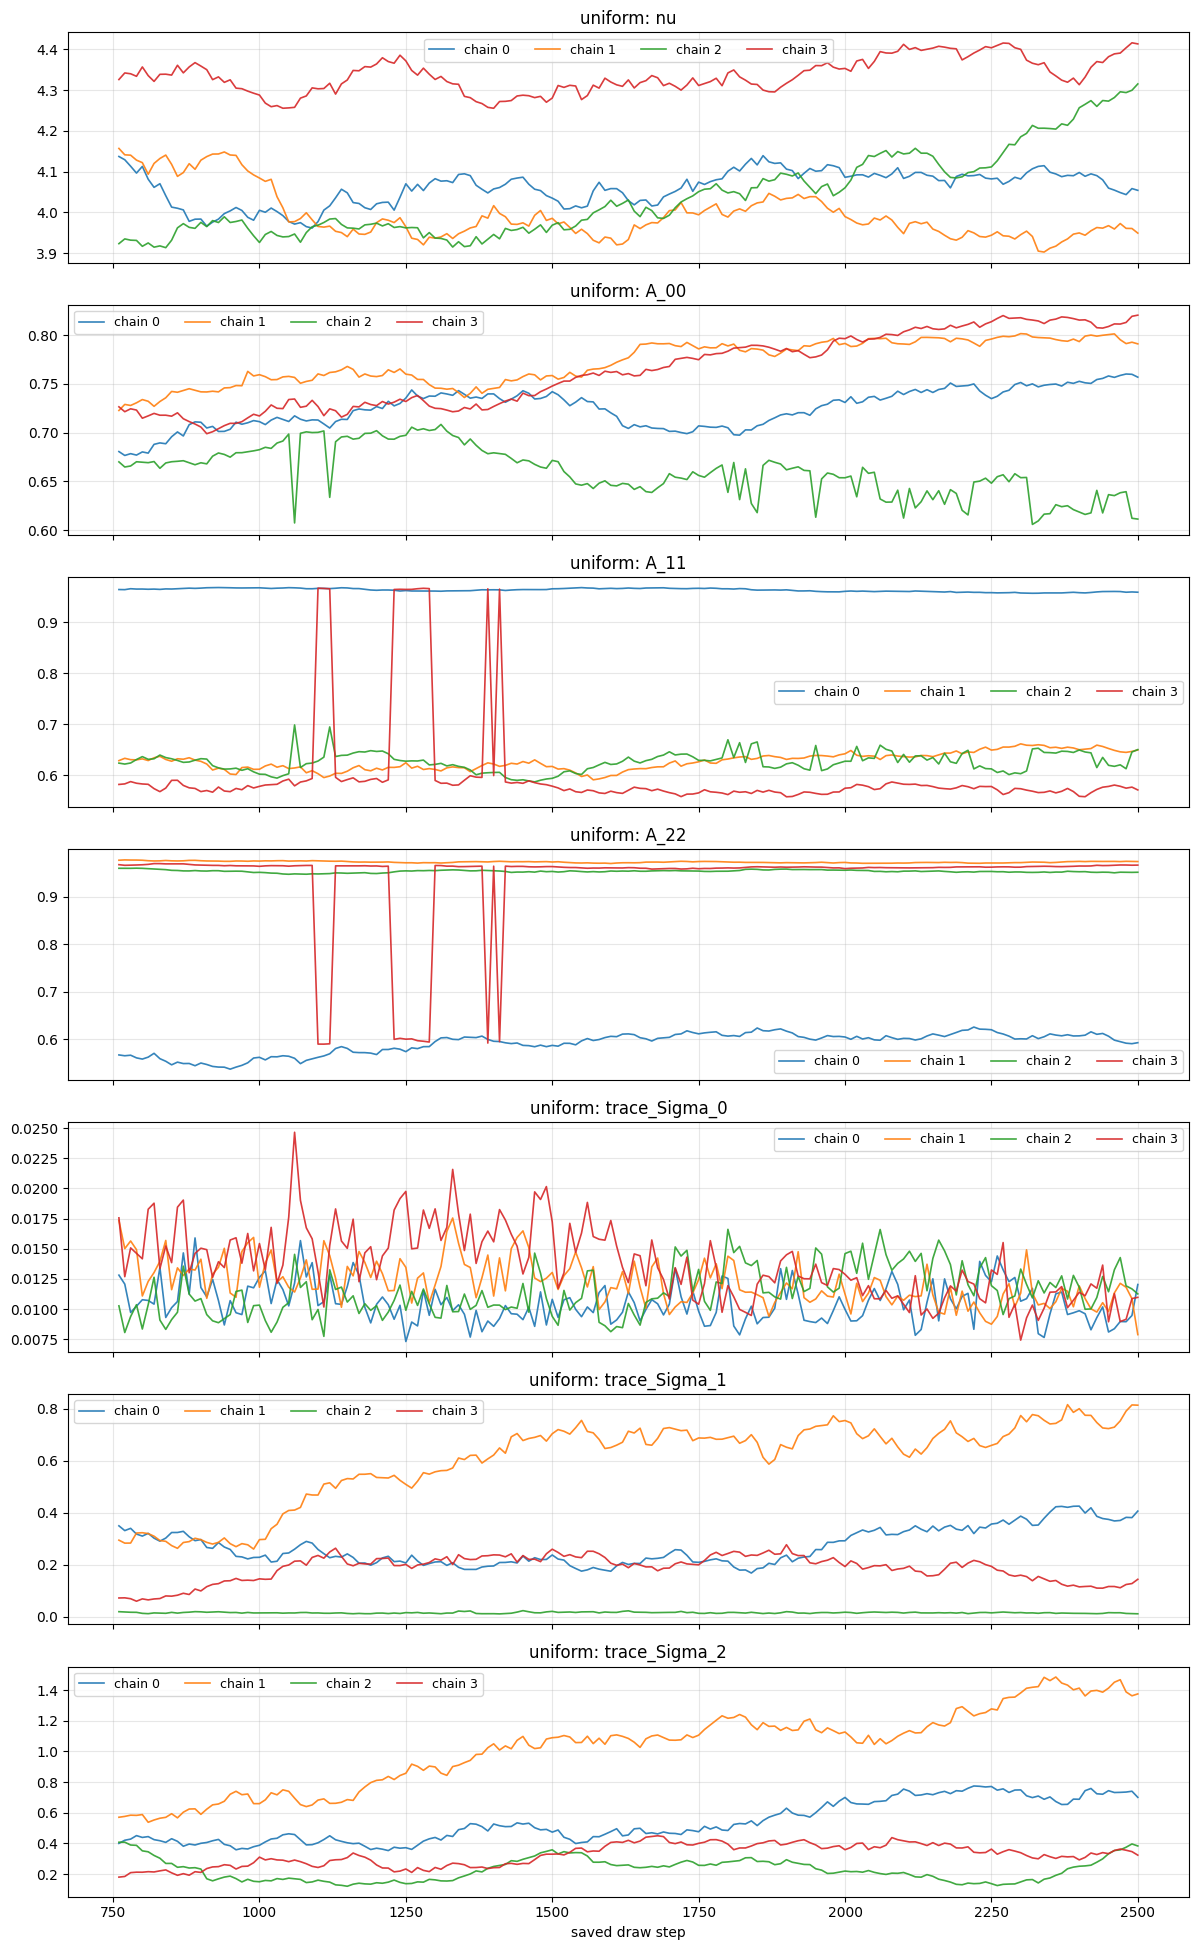

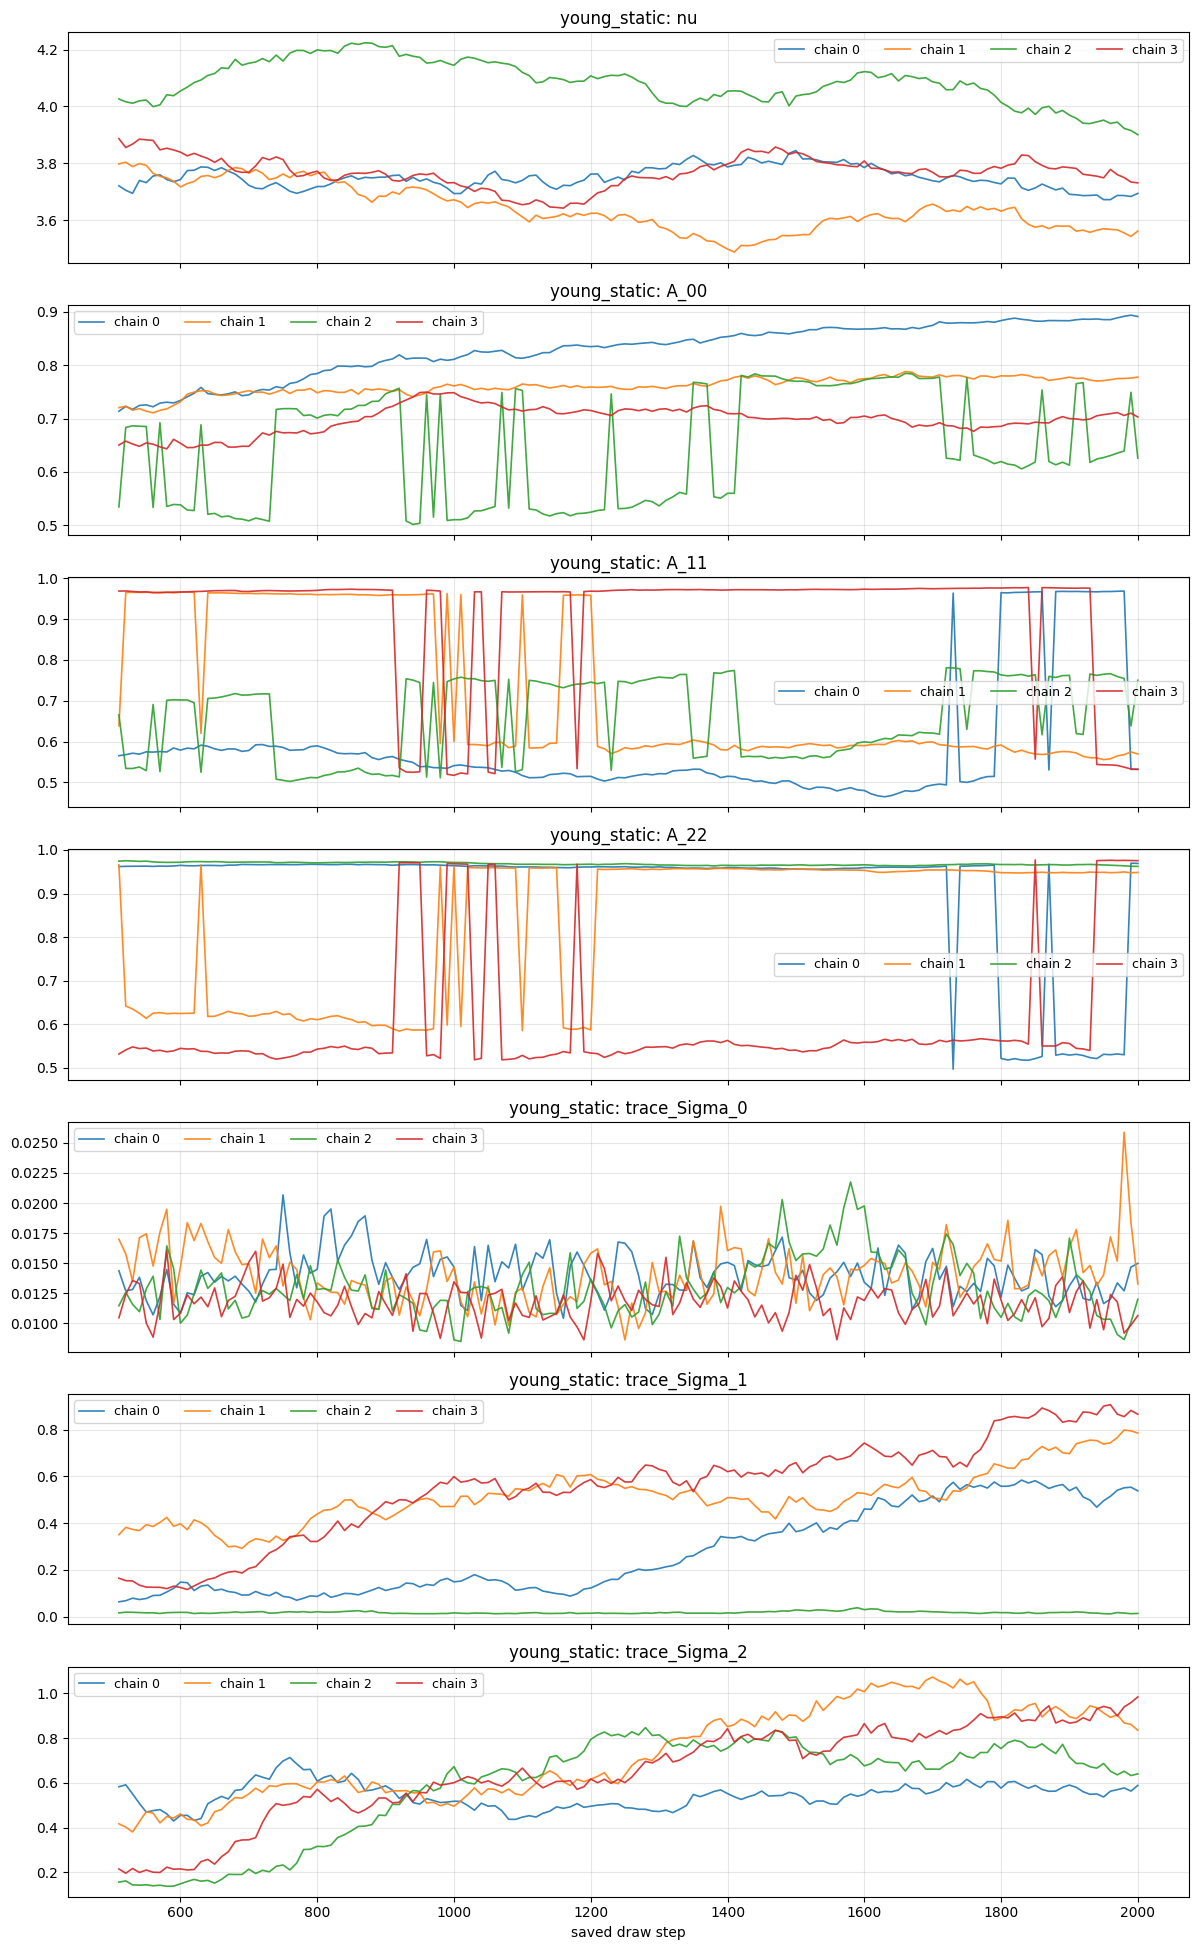

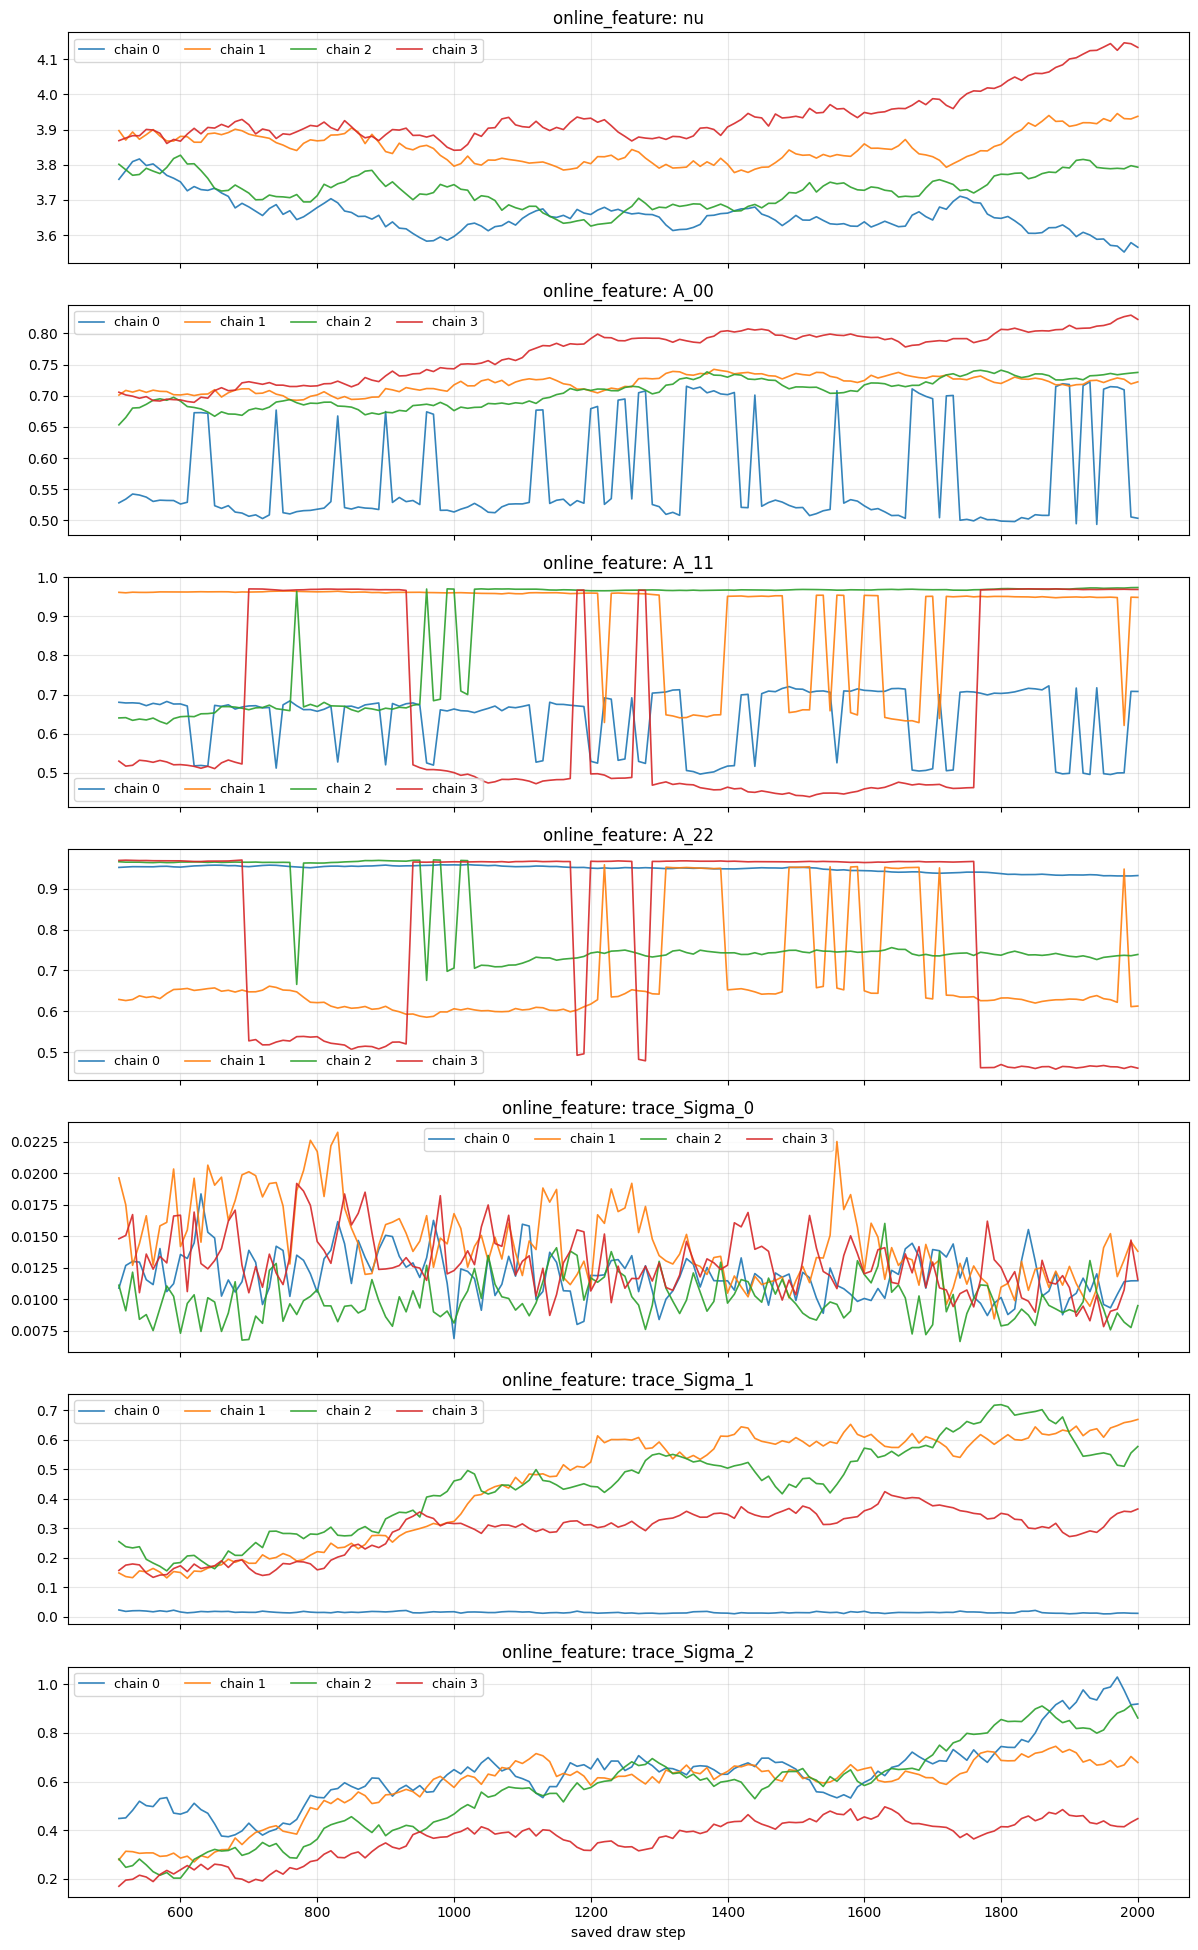

In [59]:
def plot_trace_grid(method_name, chain_dfs, vars_to_plot):
    n_vars = len(vars_to_plot)
    fig, axes = plt.subplots(n_vars, 1, figsize=(12, 2.8 * n_vars), sharex=True)
    if n_vars == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_to_plot):
        for chain_id, df in enumerate(chain_dfs):
            if var in df.columns:
                ax.plot(df['step'], df[var], lw=1.2, alpha=0.9, label=f'chain {chain_id}')
        ax.set_title(f'{method_name}: {var}')
        ax.grid(alpha=0.3)
        ax.legend(ncol=min(len(chain_dfs), 4), fontsize=9)

    axes[-1].set_xlabel('saved draw step')
    plt.tight_layout()
    plt.show()


for method_name, out in method_diagnostics.items():
    plot_trace_grid(method_name, out['chain_dfs'], TRACE_VARS)

## Smoothed regime comparison

This compares the saved smoothed probability of the highest-volatility state across the latest runs.

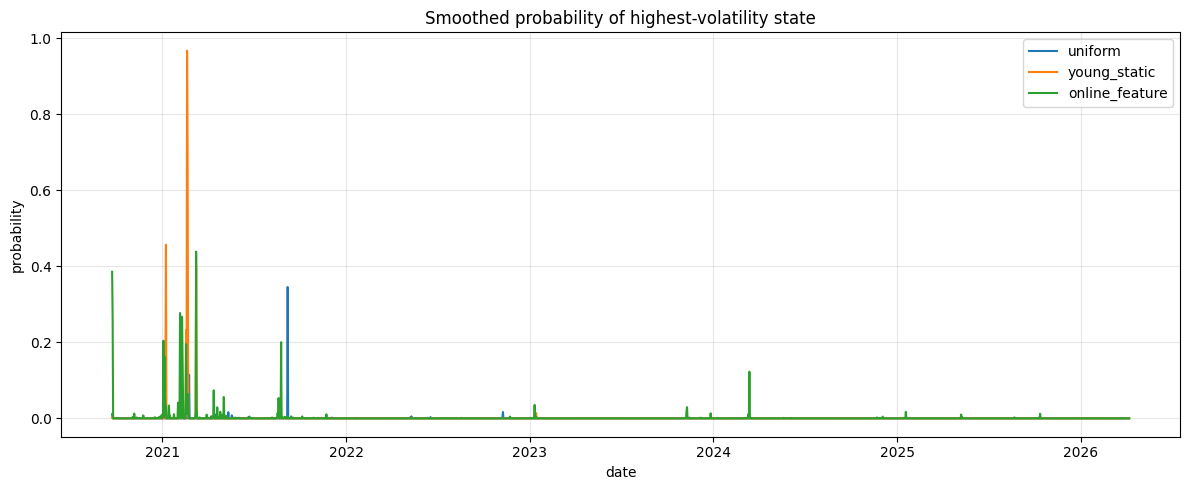

In [61]:
smoothed_by_method = {method: load_smoothed_probs(run_dir) for method, run_dir in METHOD_DIRS.items()}

plt.figure(figsize=(12, 5))
for method_name, sm_df in smoothed_by_method.items():
    plt.plot(pd.to_datetime(sm_df['date']), sm_df['state_2_prob'], label=method_name, lw=1.5)

plt.title('Smoothed probability of highest-volatility state')
plt.xlabel('date')
plt.ylabel('probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cross-method diagnostics heatmaps

These heatmaps make it easier to compare methods at a glance. The first focuses on `R-hat`, and the second shows bulk ESS on a log scale so large differences are easier to see.

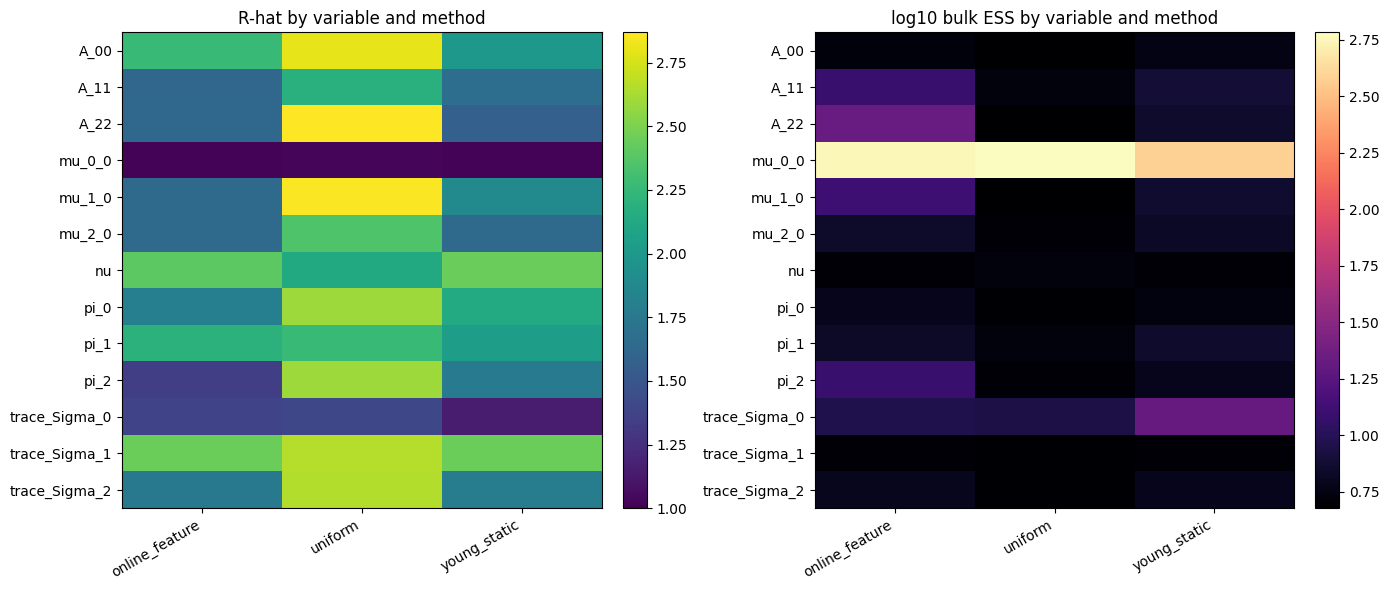

In [63]:
rhat_heatmap = (
    pd.concat(
        [out['diag_df'].assign(method=method_name) for method_name, out in method_diagnostics.items()],
        ignore_index=True,
    )
    .pivot(index='variable', columns='method', values='rhat')
    .sort_index()
)

ess_heatmap = (
    pd.concat(
        [out['diag_df'].assign(method=method_name) for method_name, out in method_diagnostics.items()],
        ignore_index=True,
    )
    .pivot(index='variable', columns='method', values='ess_bulk')
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, 0.45 * len(rhat_heatmap))))

im0 = axes[0].imshow(rhat_heatmap.to_numpy(), aspect='auto', cmap='viridis', vmin=1.0, vmax=max(1.05, np.nanmax(rhat_heatmap.to_numpy())))
axes[0].set_title('R-hat by variable and method')
axes[0].set_xticks(range(len(rhat_heatmap.columns)))
axes[0].set_xticklabels(rhat_heatmap.columns, rotation=30, ha='right')
axes[0].set_yticks(range(len(rhat_heatmap.index)))
axes[0].set_yticklabels(rhat_heatmap.index)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

log_ess = np.log10(np.clip(ess_heatmap.to_numpy(), 1.0, np.inf))
im1 = axes[1].imshow(log_ess, aspect='auto', cmap='magma')
axes[1].set_title('log10 bulk ESS by variable and method')
axes[1].set_xticks(range(len(ess_heatmap.columns)))
axes[1].set_xticklabels(ess_heatmap.columns, rotation=30, ha='right')
axes[1].set_yticks(range(len(ess_heatmap.index)))
axes[1].set_yticklabels(ess_heatmap.index)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Posterior interval comparison for key parameters

This view compares posterior medians and 90% intervals for a few interpretable summaries: tail-heaviness `nu`, within-state persistence, and covariance scale.

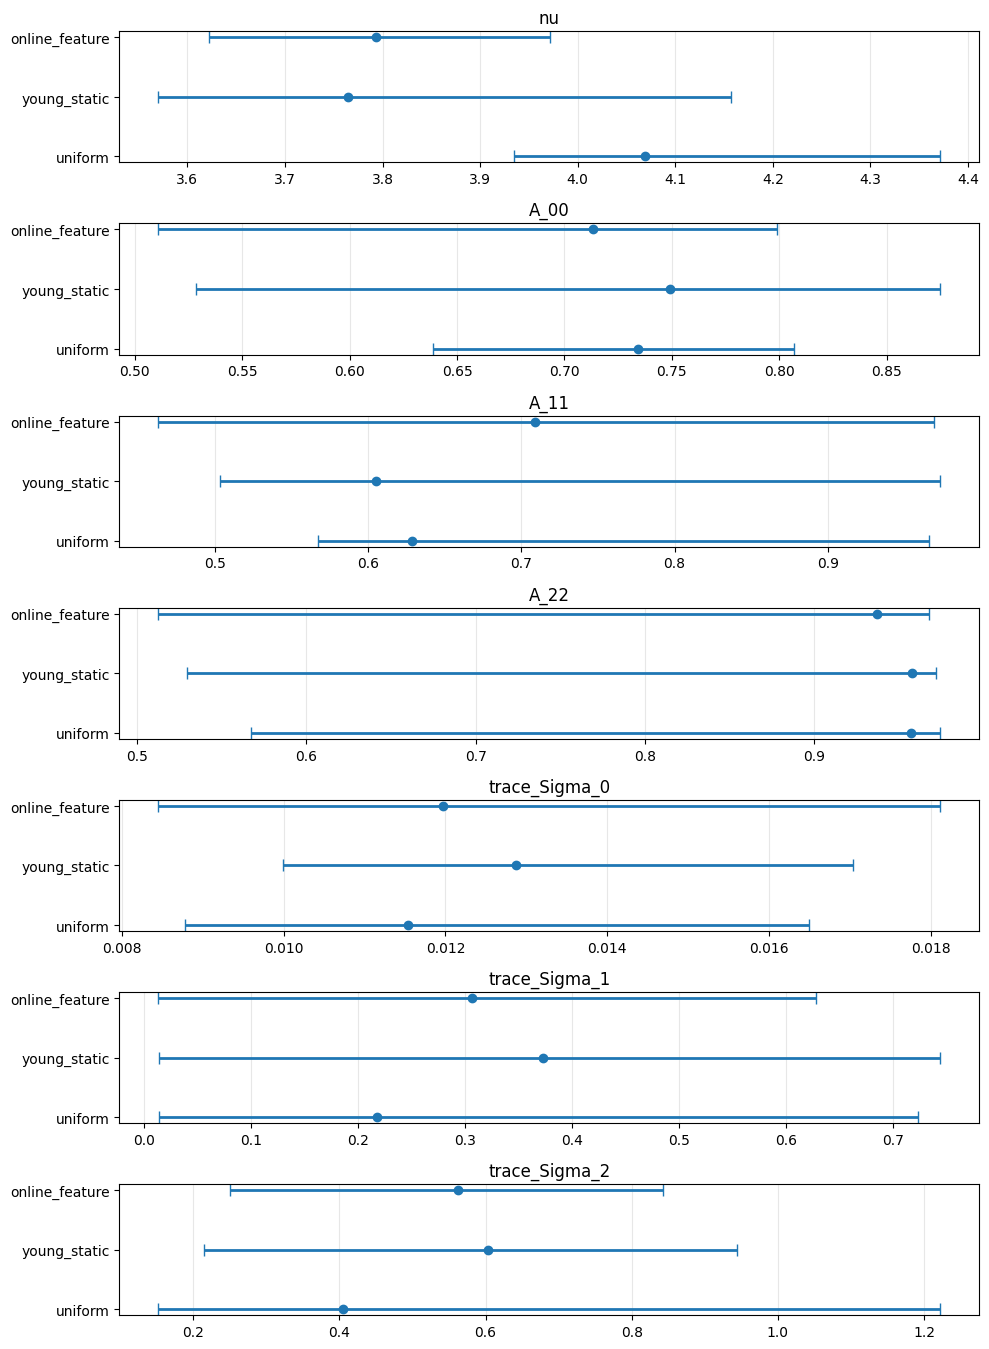

In [65]:
KEY_INTERVAL_VARS = [
    'nu',
    'A_00', 'A_11', 'A_22',
    'trace_Sigma_0', 'trace_Sigma_1', 'trace_Sigma_2',
]

interval_rows = []
for method_name, out in method_diagnostics.items():
    combined = pd.concat(out['chain_dfs'], ignore_index=True)
    for var in KEY_INTERVAL_VARS:
        if var not in combined.columns:
            continue
        values = combined[var].to_numpy()
        interval_rows.append({
            'method': method_name,
            'variable': var,
            'q05': float(np.quantile(values, 0.05)),
            'median': float(np.quantile(values, 0.50)),
            'q95': float(np.quantile(values, 0.95)),
        })

interval_df = pd.DataFrame(interval_rows)
vars_present = [v for v in KEY_INTERVAL_VARS if v in interval_df['variable'].unique()]
fig, axes = plt.subplots(len(vars_present), 1, figsize=(10, 1.0 + 1.8 * len(vars_present)), sharex=False)
if len(vars_present) == 1:
    axes = [axes]

method_order = list(method_diagnostics.keys())
y_positions = np.arange(len(method_order))

for ax, var in zip(axes, vars_present):
    sub = interval_df[interval_df['variable'] == var].set_index('method').loc[method_order].reset_index()
    lower = sub['median'] - sub['q05']
    upper = sub['q95'] - sub['median']
    ax.errorbar(sub['median'], y_positions, xerr=[lower, upper], fmt='o', capsize=4, lw=2)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(method_order)
    ax.set_title(var)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Regime occupancy summary

This summarizes how often each method places mass on each regime. The left panel uses average smoothed probabilities, and the right panel uses the most-likely state frequency.

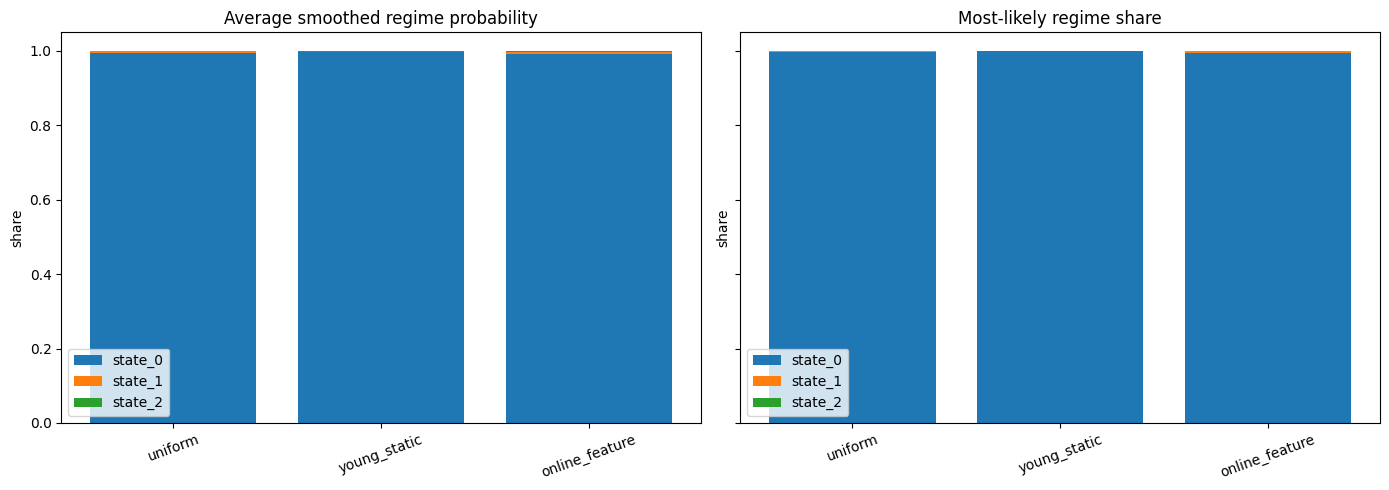

In [69]:
occupancy_rows = []
ml_rows = []
for method_name, sm_df in smoothed_by_method.items():
    state_cols = [c for c in sm_df.columns if c.startswith('state_') and c.endswith('_prob')]
    state_cols = sorted(state_cols, key=lambda c: int(c.split('_')[1]))
    avg_probs = sm_df[state_cols].mean(axis=0)
    ml_state = sm_df[state_cols].to_numpy().argmax(axis=1)
    ml_freq = pd.Series(ml_state).value_counts(normalize=True).sort_index()

    for state_idx, col in enumerate(state_cols):
        occupancy_rows.append({
            'method': method_name,
            'state': f'state_{state_idx}',
            'avg_prob': float(avg_probs[col]),
        })
        ml_rows.append({
            'method': method_name,
            'state': f'state_{state_idx}',
            'ml_share': float(ml_freq.get(state_idx, 0.0)),
        })

occupancy_df = pd.DataFrame(occupancy_rows)
ml_df = pd.DataFrame(ml_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, df, value_col, title in [
    (axes[0], occupancy_df, 'avg_prob', 'Average smoothed regime probability'),
    (axes[1], ml_df, 'ml_share', 'Most-likely regime share'),
]:
    pivot = df.pivot(index='method', columns='state', values=value_col).loc[list(method_diagnostics.keys())]
    bottom = np.zeros(len(pivot))
    for state in pivot.columns:
        vals = pivot[state].to_numpy()
        ax.bar(pivot.index, vals, bottom=bottom, label=state)
        bottom += vals
    ax.set_title(title)
    ax.set_ylabel('share')
    ax.tick_params(axis='x', rotation=20)
    ax.legend()

plt.tight_layout()
plt.show()

## High-volatility state distribution over time

Instead of only plotting the time series, this shows the distribution of the smoothed probability assigned to the highest-volatility state. It is a quick visual sense of how often each method is confidently in a stressed regime.

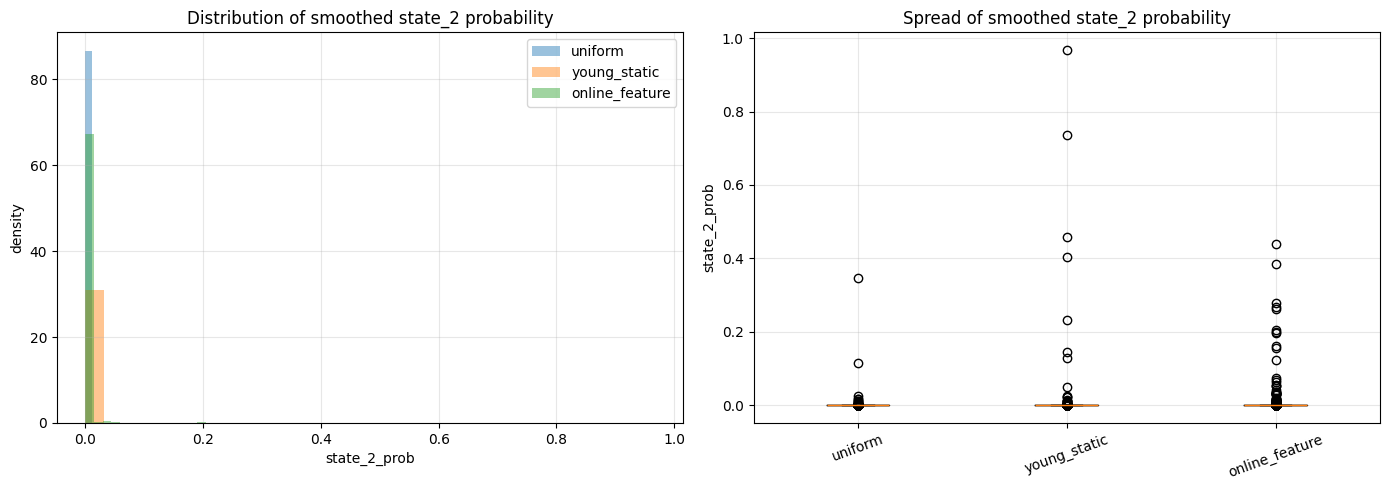

In [74]:
state2_rows = []
for method_name, sm_df in smoothed_by_method.items():
    for value in sm_df['state_2_prob'].to_numpy():
        state2_rows.append({'method': method_name, 'state_2_prob': float(value)})

state2_df = pd.DataFrame(state2_rows)
method_order = list(method_diagnostics.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method_name in method_order:
    sub = state2_df[state2_df['method'] == method_name]
    axes[0].hist(sub['state_2_prob'], bins=30, alpha=0.45, density=True, label=method_name)
axes[0].set_title('Distribution of smoothed state_2 probability')
axes[0].set_xlabel('state_2_prob')
axes[0].set_ylabel('density')
axes[0].grid(alpha=0.3)
axes[0].legend()

box_data = [state2_df[state2_df['method'] == method_name]['state_2_prob'].to_numpy() for method_name in method_order]
axes[1].boxplot(box_data, labels=method_order, vert=True)
axes[1].set_title('Spread of smoothed state_2 probability')
axes[1].set_ylabel('state_2_prob')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Optional: save the compact diagnostics table

Uncomment the last line if you want to write the compact diagnostics table to disk.

In [20]:
DIAG_OUT = RESULTS_DIR / 'diagnostics_outputs'
DIAG_OUT.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(DIAG_OUT / 'latest_run_chain_diagnostics_summary.csv', index=False)
summary_df
# summary_df.to_pickle(DIAG_OUT / 'latest_run_chain_diagnostics_summary.pkl')

,method,n_chains,draws_per_chain_used,max_rhat,min_ess_bulk,min_ess_tail,mean_runtime_sec,run_dir
1,young_static,4,150,2.448896,5.044771,11.756590,8705.256241,/Users/diego/Stat 221/crypto_stage1_processed/...
2,online_feature,4,150,2.450613,5.034339,11.375010,11695.375489,/Users/diego/Stat 221/crypto_stage1_processed/...
0,uniform,4,175,2.869300,4.743959,11.340743,6278.521743,/Users/diego/Stat 221/crypto_stage1_processed/...
